<a href="https://colab.research.google.com/github/jonibek21-ML/Baseline-model-for-MLP/blob/main/Project6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# My Code


# 📚 Libraries & Setup
Bu bo‘limda PyTorch, NumPy, Matplotlib va Sklearn kutubxonalarini import qilamiz. Shuningdek, device (`CPU` yoki `GPU`) tanlaymiz.

In [75]:
import pandas as pd
df = pd.read_csv("/content/diabetes.csv")

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,recall_score,r2_score
import torch
import numpy
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

# 🗂 Data Load & View
Bu bo‘limda datasetni pandas orqali yuklaymiz, uni PyTorch tensorlariga aylantiramiz va qisqacha ma'lumotini ko‘ramiz:
- `x_train`, `y_train` shapes
- `x_test`, `y_test` shapes
- Class balance tekshiruvi

In [77]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [78]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [80]:
scaler = StandardScaler()
x = df.drop(columns=["Outcome"]).values
y = df["Outcome"].values
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=20,stratify=y)
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

# 🔀 Train & Test Split
Datasetni training va testing qismlarga ajratamiz.
- Training uchun DataLoader yaratamiz (`batch_size=16`)
- Testing uchun DataLoader yaratamiz (`batch_size=16`)

In [81]:
x_train = torch.tensor(x_train, dtype=torch.float)
x_test  = torch.tensor(x_test, dtype=torch.float)

y_train = torch.tensor(y_train, dtype=torch.float).view(-1,1)
y_test  = torch.tensor(y_test, dtype=torch.float).view(-1,1)

tr_data = torch.utils.data.TensorDataset(x_train,y_train)
te_data = torch.utils.data.TensorDataset(x_test,y_test)

tr_load = torch.utils.data.DataLoader(tr_data,batch_size=16,shuffle=True)
te_load = torch.utils.data.DataLoader(te_data,batch_size=16,shuffle=False)

# 🏗 Model Definition
Bu bo‘limda neural network arxitekturamizni yaratamiz:
- 3 Fully Connected qatlam (Linear)
- ReLU activation
- Dropout regularization
- Sigmoid output (binary classification uchun)

In [82]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = nn.Sequential(
    nn.Linear(8,32),
    nn.ReLU(),
    nn.Dropout(0.25),

    nn.Linear(32,128),
    nn.ReLU(),
    nn.Dropout(0.25),

    nn.Linear(128,1),
    nn.Sigmoid()

).to(device)

In [83]:
optim = torch.optim.Adam(model.parameters(),lr=0.001)
crite = nn.BCELoss()

# 🚀 Model Training
Training loop-ni yaratamiz:
- Loss: `BCELoss` (binary)
- Optimizer: `Adam`
- Epoch-wise loss va accuracy monitoring
- Device (`CPU` yoki `GPU`) bilan mos ishlash

In [84]:
for epoch in range(100):
  model.train()
  rn_loss = 0
  for dx,dy in tr_load:
    dx = dx.to(device)
    dy = dy.to(device)
    optim.zero_grad()
    pred = model(dx)
    loss = crite(pred,dy)
    loss.backward()
    optim.step()
    rn_loss += loss.item()

    dy_np   = dy.detach().cpu().numpy().astype(int)
    pred_np = pred.detach().cpu().numpy().astype(int)
    acc = accuracy_score(dy_np, pred_np)
  if (epoch + 1) % 10 == 0:
    print(f"| Epoch:[{epoch+1:03d}/100] | Loss:{rn_loss:.2f} | Accuracy:{acc:.2f} |")

| Epoch:[010/100] | Loss:21.53 | Accuracy:0.58 |
| Epoch:[020/100] | Loss:20.64 | Accuracy:0.58 |
| Epoch:[030/100] | Loss:20.14 | Accuracy:0.50 |
| Epoch:[040/100] | Loss:20.03 | Accuracy:0.67 |
| Epoch:[050/100] | Loss:19.12 | Accuracy:0.67 |
| Epoch:[060/100] | Loss:19.25 | Accuracy:0.58 |
| Epoch:[070/100] | Loss:18.92 | Accuracy:0.42 |
| Epoch:[080/100] | Loss:18.49 | Accuracy:0.75 |
| Epoch:[090/100] | Loss:19.04 | Accuracy:0.75 |
| Epoch:[100/100] | Loss:18.04 | Accuracy:0.75 |


# 🔍 Model Evaluation
Test set bo‘yicha modelni baholaymiz:
- Batch-wise forward pass
- Predictions va true labels yig‘ish
- Accuracy va Recall hisoblash

In [100]:
model.eval()
all_dy = []
all_pr = []
with torch.no_grad():
  for dx,dy in te_load:
    dx = dx.to(device)
    pr = model(dx)
    all_dy.append(dy.numpy().astype(int))
    all_pr.append((pr.cpu().numpy() > 0.4).astype(int))
all_dy = numpy.concatenate(all_dy)
all_pr = numpy.concatenate(all_pr)
print(f"Accuracy Score: {accuracy_score(all_dy,all_pr)}%")
print(f"Recall Score: {recall_score(all_dy,all_pr,zero_division=0):.2f}")

Accuracy Score: 0.75%
Recall Score: 0.71


# 📊 Confusion Matrix Plot
Sklearn `confusion_matrix` va `ConfusionMatrixDisplay` yordamida modelning performance-ni vizual ko‘rsatamiz:
- True Positive, True Negative, False Positive, False Negative

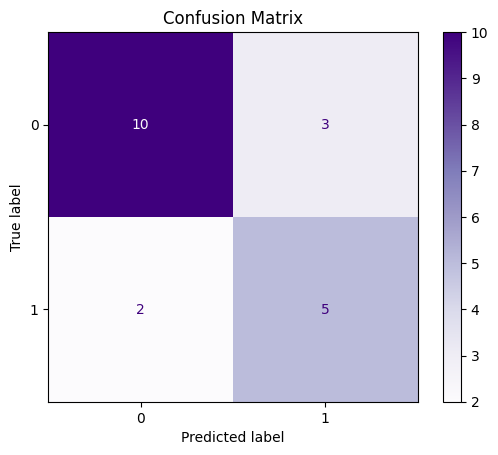

In [98]:
cm = confusion_matrix(all_dy, all_pr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Purples)
plt.title("Confusion Matrix")
plt.show()